# Implementing and experimenting with Deutsch--Jozsa

This notebook implements the algorithm and reproduces the experiments used in the reference solution.

In [ ]:
# Run this cell in Google Colab.
%pip install -q qiskit qiskit-aer matplotlib

In [2]:
import math

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

def input_size(truth_table):
    """Validate a truth table and return its number of input bits."""
    if not truth_table or set(truth_table) - {"0", "1"}:
        raise ValueError("the truth table must be a nonempty bitstring")
    length = len(truth_table)
    if length < 2 or length & (length - 1):
        raise ValueError("the truth-table length must be a power of two of at least 2")
    return int(math.log2(length))

def oracle(truth_table):
    """Construct |x,y> -> |x,y xor f(x)> from a truth table."""
    n = input_size(truth_table)
    circuit = QuantumCircuit(n + 1, name="U_f")
    controls = list(range(n))
    target = n

    # Synthesizing the less frequent output value keeps complementary oracles
    # comparable and makes both constant functions inexpensive.
    complement = truth_table.count("1") > len(truth_table) // 2
    selected_value = "0" if complement else "1"
    if complement:
        circuit.x(target)

    for x, value in enumerate(truth_table):
        if value != selected_value:
            continue
        zero_controls = [qubit for qubit in controls if not (x >> qubit) & 1]
        if zero_controls:
            circuit.x(zero_controls)
        circuit.mcx(controls, target)
        if zero_controls:
            circuit.x(zero_controls)

    return circuit

def circuit(truth_table):
    """Construct the complete Deutsch--Jozsa circuit."""
    n = input_size(truth_table)
    result = QuantumCircuit(n + 1, n)
    result.x(n)
    result.h(range(n + 1))
    result.compose(oracle(truth_table), inplace=True)
    result.h(range(n))
    result.measure(range(n), range(n))
    return result

def depolarizing_noise(two_qubit_error):
    """Create the noise model used in the exercise."""
    if not 0 <= two_qubit_error <= 1:
        raise ValueError("the error probability must lie in [0,1]")
    model = NoiseModel()
    model.add_all_qubit_quantum_error(
        depolarizing_error(two_qubit_error / 10, 1), ["u"]
    )
    model.add_all_qubit_quantum_error(
        depolarizing_error(two_qubit_error, 2), ["cx"]
    )
    return model

def run(truth_table, shots=1, two_qubit_error=None, seed=None):
    """Simulate the circuit and return measurement counts."""
    if shots < 1:
        raise ValueError("shots must be positive")

    noise = None if two_qubit_error is None else depolarizing_noise(two_qubit_error)
    simulator = AerSimulator(noise_model=noise)
    if noise is None:
        compiled = transpile(circuit(truth_table), simulator, optimization_level=1)
    else:
        # The noise model is defined on generic one-qubit gates and CX gates.
        compiled = transpile(
            circuit(truth_table), basis_gates=["u", "cx"], optimization_level=1
        )
    job = simulator.run(compiled, shots=shots, seed_simulator=seed)
    return dict(job.result().get_counts())

def classify(truth_table, seed=None):
    """Perform one ideal execution and return the Deutsch--Jozsa answer."""
    n = input_size(truth_table)
    counts = run(truth_table, shots=1, seed=seed)
    measured = next(iter(counts))
    return "constant" if measured == "0" * n else "balanced"

The implementation constructs an ancilla-based oracle directly from the truth table. For example, the following balanced function is classified from 100 ideal executions.

In [3]:
example = "0" * 16 + "1" * 16
example_counts = run(example, shots=100, seed=13013)
print(example_counts)
print(classify(example, seed=13013))

{'10000': 100}
balanced


## Experiments

The experiments used for the reference solution are available below. They select the constant or balanced class independently with equal probability in each promised-function trial and sample fixed-weight truth tables in the imbalance experiment.

In [4]:
import random
import matplotlib.pyplot as plt

def shuffled_table(size, ones, rng):
    values = ["1"] * ones + ["0"] * (size - ones)
    rng.shuffle(values)
    return "".join(values)

def success_count(truth_table, expected, shots, seed, error=None):
    n = input_size(truth_table)
    counts = run(truth_table, shots=shots, two_qubit_error=error, seed=seed)
    zero_count = counts.get("0" * n, 0)
    return zero_count if expected == "constant" else shots - zero_count

def summarize(successes, observations):
    rate = successes / observations
    standard_error = math.sqrt(rate * (1 - rate) / observations)
    return rate, standard_error

def evaluate(tables, expected, shots, rng, error=None):
    successes = sum(
        success_count(table, expected, shots, rng.randrange(2**32), error)
        for table in tables
    )
    observations = len(tables) * shots
    rate, standard_error = summarize(successes, observations)
    return len(tables), observations, rate, standard_error

In [5]:
n = 5
size = 2**n
trials = 20
shots = 100
rng = random.Random(13013)

tables = {"constant": [], "balanced": []}
for _ in range(trials):
    label = rng.choice(["constant", "balanced"])
    if label == "constant":
        table = rng.choice("01") * size
    else:
        table = shuffled_table(size, size // 2, rng)
    tables[label].append(table)

print({label: len(items) for label, items in tables.items()})

{'constant': 10, 'balanced': 10}


### (a) Results for the ideal simulation

In [6]:
ideal_results = {}
for label in ["constant", "balanced"]:
    count, observations, rate, standard_error = evaluate(
        tables[label], label, shots, rng
    )
    ideal_results[label] = rate, standard_error
    print(
        f"{label:8} trials={count:2} shots={shots:3} "
        f"success={rate:.4f} SE={standard_error:.4f}"
    )

constant trials=10 shots=100 success=1.0000 SE=0.0000


balanced trials=10 shots=100 success=1.0000 SE=0.0000


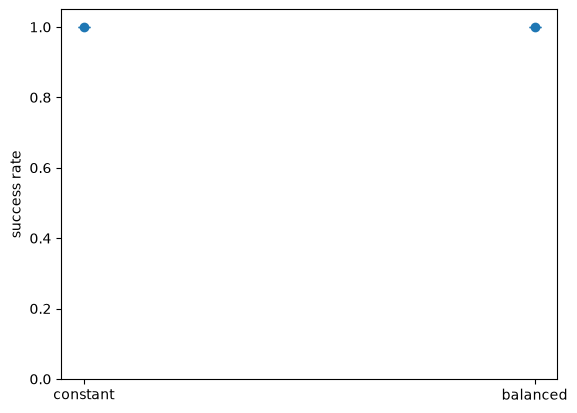

In [7]:
labels = list(ideal_results)
rates = [ideal_results[label][0] for label in labels]
errors = [ideal_results[label][1] for label in labels]
plt.errorbar(labels, rates, yerr=errors, fmt="o", capsize=4)
plt.ylim(0, 1.05)
plt.ylabel("success rate")
plt.show()

### (b) Results for the noisy simulation

The two-qubit depolarizing error is $p$ and the one-qubit error is $p/10$.

In [8]:
error_rates = [10.0**-k for k in range(2, 7)]
noisy_results = {"constant": [], "balanced": []}

for error in error_rates:
    for label in ["constant", "balanced"]:
        count, observations, rate, standard_error = evaluate(
            tables[label], label, shots, rng, error
        )
        noisy_results[label].append((rate, standard_error))
        print(
            f"p={error:.0e} {label:8} trials={count:2} shots={shots:3} "
            f"success={rate:.4f} SE={standard_error:.4f}"
        )

p=1e-02 constant trials=10 shots=100 success=1.0000 SE=0.0000


p=1e-02 balanced trials=10 shots=100 success=0.9630 SE=0.0060
p=1e-03 constant trials=10 shots=100 success=1.0000 SE=0.0000


p=1e-03 balanced trials=10 shots=100 success=0.9620 SE=0.0060
p=1e-04 constant trials=10 shots=100 success=1.0000 SE=0.0000


p=1e-04 balanced trials=10 shots=100 success=0.9980 SE=0.0014
p=1e-05 constant trials=10 shots=100 success=1.0000 SE=0.0000


p=1e-05 balanced trials=10 shots=100 success=0.9990 SE=0.0010
p=1e-06 constant trials=10 shots=100 success=1.0000 SE=0.0000


p=1e-06 balanced trials=10 shots=100 success=1.0000 SE=0.0000


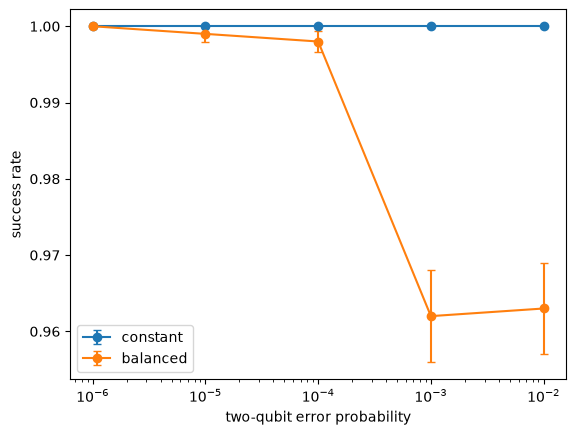

In [9]:
for label in ["constant", "balanced"]:
    rates = [result[0] for result in noisy_results[label]]
    errors = [result[1] for result in noisy_results[label]]
    plt.errorbar(error_rates, rates, yerr=errors, marker="o", capsize=3, label=label)
plt.xscale("log")
plt.xlabel("two-qubit error probability")
plt.ylabel("success rate")
plt.legend()
plt.show()

### (c) Results for non-promise truth tables

For an arbitrary truth table, the amplitude of $|0^n\rangle$ is $(N_0-N_1)/N$. A nonconstant function with imbalance $d$ is therefore detected with probability $1-d^2$.

In [10]:
ones_values = [17, 20, 24, 28, 30, 31]
imbalance_results = []

for ones in ones_values:
    sampled_tables = [shuffled_table(size, ones, rng) for _ in range(trials)]
    count, observations, rate, standard_error = evaluate(
        sampled_tables, "nonconstant", shots, rng
    )
    imbalance = abs(size - 2 * ones) / size
    theory = 1 - imbalance**2
    imbalance_results.append((imbalance, rate, standard_error, theory))
    print(
        f"d={imbalance:.4f} ones={ones:2} trials={count:2} shots={shots:3} "
        f"success={rate:.4f} SE={standard_error:.4f} theory={theory:.4f}"
    )

d=0.0625 ones=17 trials=20 shots=100 success=0.9955 SE=0.0015 theory=0.9961


d=0.2500 ones=20 trials=20 shots=100 success=0.9380 SE=0.0054 theory=0.9375


d=0.5000 ones=24 trials=20 shots=100 success=0.7370 SE=0.0098 theory=0.7500


d=0.7500 ones=28 trials=20 shots=100 success=0.4335 SE=0.0111 theory=0.4375


d=0.8750 ones=30 trials=20 shots=100 success=0.2275 SE=0.0094 theory=0.2344


d=0.9375 ones=31 trials=20 shots=100 success=0.1330 SE=0.0076 theory=0.1211


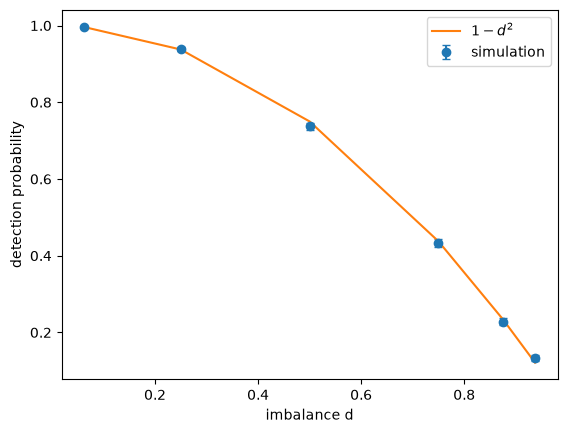

In [11]:
imbalances = [result[0] for result in imbalance_results]
rates = [result[1] for result in imbalance_results]
errors = [result[2] for result in imbalance_results]
theory = [result[3] for result in imbalance_results]
plt.errorbar(imbalances, rates, yerr=errors, fmt="o", capsize=3, label="simulation")
plt.plot(imbalances, theory, label=r"$1-d^2$")
plt.xlabel("imbalance d")
plt.ylabel("detection probability")
plt.legend()
plt.show()